# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

d = np.genfromtxt(f'data_03.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 0.80 ppt


In [25]:
from scipy.interpolate import make_splrep
from scipy.optimize._numdiff import approx_derivative
from scipy import stats
from scipy.ndimage import median_filter

## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

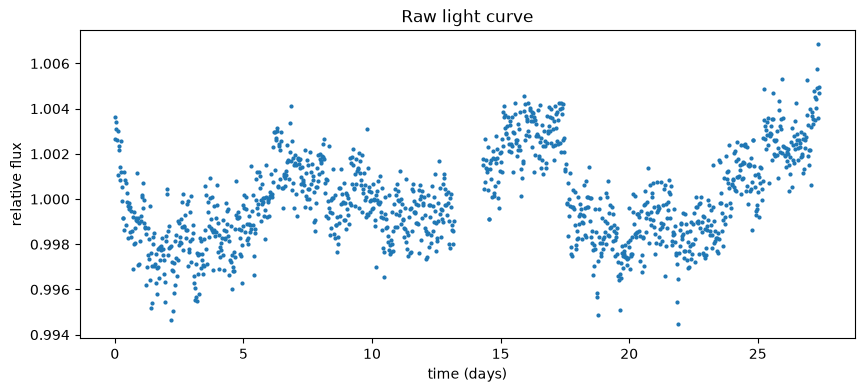

In [26]:
# Part 1: your work here
plt.figure(figsize=(10, 4))
plt.plot(t,flux,'o', ms=2)
plt.title('Raw light curve'), plt.xlabel('time (days)'), plt.ylabel('relative flux')
plt.show()

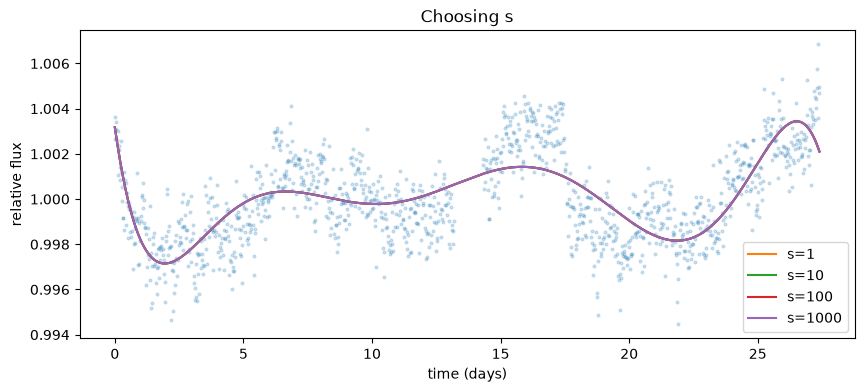

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(t, flux, 'o', ms=2, alpha=0.2)

for s in [1, 10, 100, 1000]:
    spline = make_splrep(t, flux, k=7, s=s)
    plt.plot(t, spline(t), label=f"s={s}")

plt.title('Choosing s'),plt.xlabel('time (days)'), plt.ylabel('relative flux')
plt.legend()
plt.show()

In [28]:
spline = make_splrep(t,flux,k=7,s=100)
trend = spline(t)

flux_detrend = flux / trend

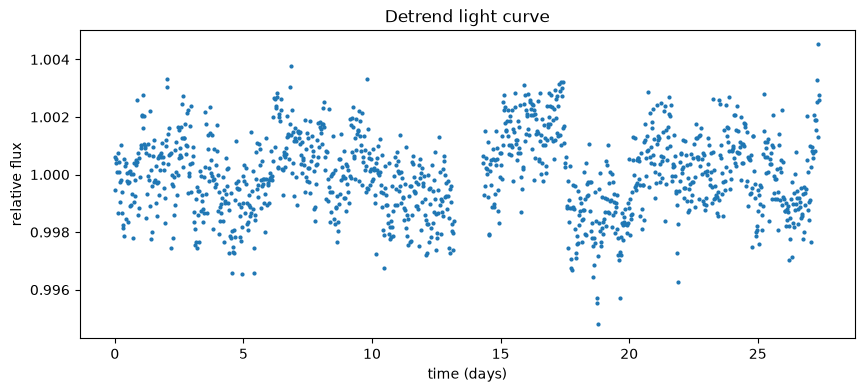

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(t, flux_detrend, 'o', ms=2, label='Detrend')
plt.title('Detrend light curve'),plt.xlabel('time (days)'), plt.ylabel('relative flux')
plt.show()

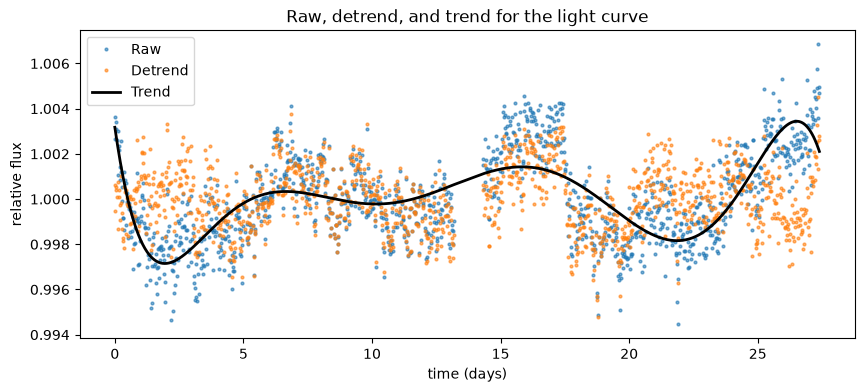

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(t, flux, 'o', ms=2, label='Raw',alpha=0.6)
plt.plot(t, flux_detrend, 'o', ms=2, label='Detrend',alpha=0.6)
plt.plot(t, trend, 'k', lw=2, label='Trend')
plt.title('Raw, detrend, and trend for the light curve'),plt.xlabel('time (days)'), plt.ylabel('relative flux')
plt.legend()
plt.show()

In [31]:
print(np.std(flux_detrend))
print(np.std(flux_detrend) - np.median(sigma))

0.0013927136934497183
0.0005897136934497183


**ANSWERS (initial guesses + scatter check):**

Initial guesses: $t_0$ = 2.5 d , $P$ = 8 d , depth = 0.0045 ppt , duration = 3 h

For the detrend I used the spline method. Comparing many values of s against each other to see which would be best. There was no notable difference in the potential values I could use so I settled on a value of 10. With a k of 7 to avoid loss of the transits.

Comparing the out-of-transit scatter of the detrended flux to the stated sigma flux, the median of out-of-transit scatter is higher.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

In [32]:
# Part 2: your work here
def neglogL(theta, t, flux, sigma):
    to, P, depth, duration, baseline = theta

    resid = flux - transit_model(t, to, P, depth, duration, baseline, ingress_frac=0.2)
    neglogL = 0.5 * np.sum((resid / sigma)**2 + np.log(2 * np.pi * sigma**2))
    
    return neglogL

theta = [2.5, 8, 0.0045, 3/24, 1]
m = minimize(neglogL, theta, args = (t, flux, sigma), method='Nelder-Mead')
to, P, depth, duration, baseline = m.x
resid = flux_detrended - transit_model(t, to, P, depth, duration, baseline, ingress_frac=0.2)

In [33]:
print(f' to = {to:.2f}')
print(f' P = {P:.2f}')
print(f' depth = {depth:.4f}')
print(f' duration = {duration:.2f}')
print(f' baseline = {baseline:.2f}')

 to = 2.24
 P = 9.43
 depth = 0.0033
 duration = 7.74
 baseline = 1.00


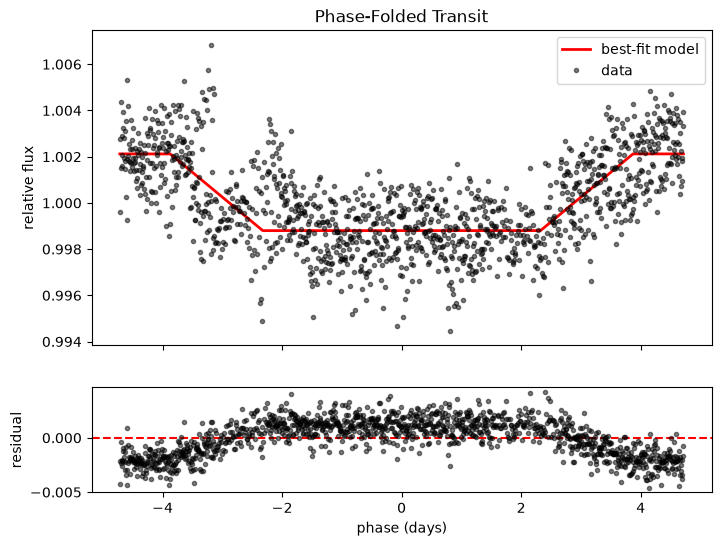

In [34]:
phase = ((t - to + 0.5 * P) % P) - 0.5 * P

model = transit_model(
    t,
    to,
    P,
    depth,
    duration,
    baseline
)

phase_model = np.linspace(-0.5 * P, 0.5 * P, 2000)
t_model = to + phase_model

model_curve = transit_model(
    t_model,
    to,
    P,
    depth,
    duration,
    baseline
)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.errorbar(
    phase,
    flux,
    fmt='.',
    color='black',
    alpha=0.5,
    label='data'
)

ax1.plot(
    phase_model,
    model_curve,
    color='red',
    lw=2,
    label='best-fit model'
)

ax1.set_ylabel("relative flux")
ax1.set_title("Phase-Folded Transit")
ax1.legend()

ax2.errorbar(
    phase,
    resid,
    fmt='.',
    color='black',
    alpha=0.5
)

ax2.axhline(0, color='red', linestyle='--')

ax2.set_xlabel("phase (days)")
ax2.set_ylabel("residual")

plt.show()

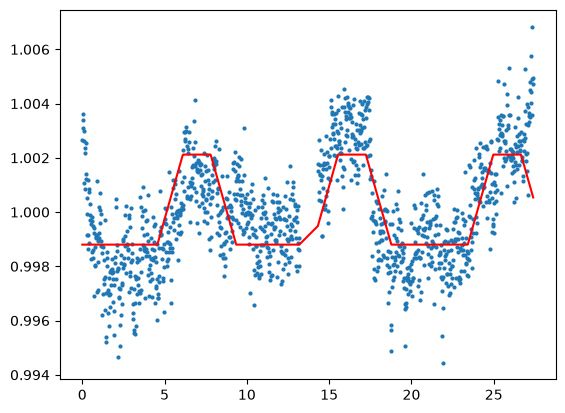

In [180]:
m_values = transit_model(t, to, P, depth, duration, baseline)

plt.plot(t, flux,'o', ms=2)
plt.plot(t, m_values, color='red')
plt.show()

In [194]:
#Hessian
theta = m.x

duration_sig = theta[3]
baseline_sig = theta[4]

H = approx_derivative(lambda p: approx_derivative(lambda x: neglogL([x[0], x[1], x[2], duration_sig, baseline_sig],t,flux,sigma),p),theta[:3])
cov = np.linalg.inv(H)

to_sig, P_sig, depth_sig = np.sqrt(np.diag(cov))

print(f'to_sig = {to_sig:.4f}')
print(f'P_sig = {P_sig:.4f}')
print(f'depth_sig = {depth_sig:.6f}')

to_sig = 0.0039
P_sig = 0.0058
depth_sig = 0.000029


In [24]:
#bootstrap - point wise
n_boot = 1000

to_boot = np.zeros(n_boot)
P_boot = np.zeros(n_boot)
depth_boot = np.zeros(n_boot)

best_theta = m.x

N = len(t)

for i in range(n_boot):
    
    idx = np.random.randint(0, N, N)

    t_bs = t[idx]
    flux_bs = flux[idx]
    sigma_bs = sigma[idx]

    order = np.argsort(t_bs)
    t_bs = t_bs[order]
    flux_bs = flux_bs[order]
    sigma_bs = sigma_bs[order]

    fit = minimize(neglogL,best_theta,args=(t_bs, flux_bs, sigma_bs),method="Nelder-Mead")

    to_boot[i] = fit.x[0]
    P_boot[i] = fit.x[1]
    depth_boot[i] = fit.x[2]

lo1, hi1 = np.percentile(to_boot, [16, 84])
lo2, hi2 = np.percentile(P_boot, [16, 84])
lo3, hi3 = np.percentile(depth_boot, [16, 84])

to_sig2 = hi1 - lo1
P_sig2 = hi2 - lo2
depth_sig2 = hi3 - lo3

print("Point-wise:")
print(f'to_sig = {to_sig2:.4f}')
print(f'P_sig = {P_sig2:.4f}')
print(f'depth_sig = {depth_sig2:.6f}')

Point-wise:
to_sig = 0.7764
P_sig = 0.4207
depth_sig = 0.000218


In [32]:
#bootstrap - block wise

n_boot = 1000

to_boot = np.zeros(n_boot)
P_boot = np.zeros(n_boot)
depth_boot = np.zeros(n_boot)

N = len(t)
dt = np.median(np.diff(np.sort(t)))
block_days = 1.0
block_len = max(2, int(round(block_days / dt)))
n_blocks = int(np.ceil(N / block_len))

for i in range(n_boot):

    chosen = np.random.randint(0,N - block_len + 1,size=n_blocks)
    idx = []

    for start in chosen:
        idx.extend(range(start, start + block_len))

    idx = np.array(idx[:N])

    t_bs = t[idx]
    flux_bs = flux[idx]
    sigma_bs = sigma[idx]

    order = np.argsort(t_bs)

    t_bs = t_bs[order]
    flux_bs = flux_bs[order]
    sigma_bs = sigma_bs[order]

    fit = minimize(neglogL,best_theta,args=(t_bs, flux_bs, sigma_bs),method="Nelder-Mead")

    to_boot[i] = fit.x[0]
    P_boot[i] = fit.x[1]
    depth_boot[i] = fit.x[2]

lo1, hi1 = np.percentile(to_boot, [16, 84])
lo2, hi2 = np.percentile(P_boot, [16, 84])
lo3, hi3 = np.percentile(depth_boot, [16, 84])

to_sig3 = hi1 - lo1
P_sig3 = hi2 - lo2
depth_sig3 = hi3 - lo3

print("Block-wise")
print(f'to_sig = {to_sig3:.4f}')
print(f'P_sig = {P_sig3:.4f}')
print(f'depth_sig = {depth_sig3:.6f}')

Block-wise
to_sig = 0.9531
P_sig = 0.5332
depth_sig = 0.000786


In [33]:
print("Point-wise & Block-wise:")
print(f'to_sig = {to_sig2:.4f} vs {to_sig3:.4f}')
print(f'P_sig = {P_sig2:.4f} vs {P_sig3:.4f}')
print(f'depth_sig = {depth_sig2:.6f} vs {depth_sig3:.6f}')

Point-wise & Block-wise:
to_sig = 0.7764 vs 0.9531
P_sig = 0.4207 vs 0.5332
depth_sig = 0.000218 vs 0.000786


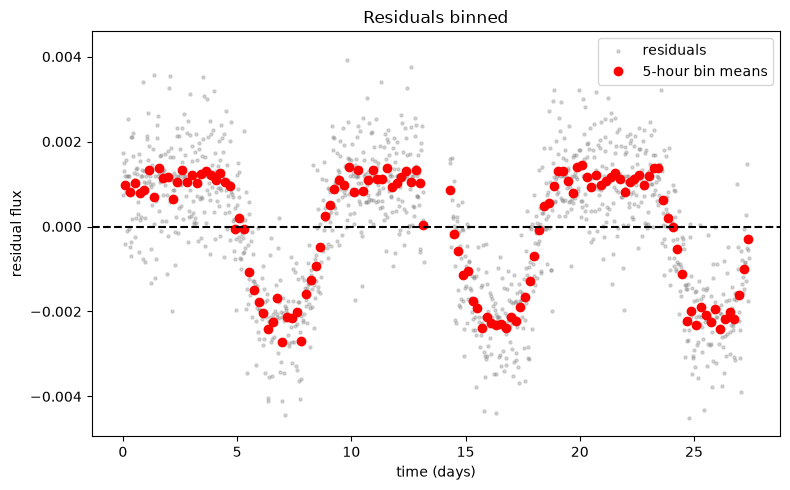

Ratio (observed/expected) = 2.6465


In [188]:
sigma_unbinned = np.std(resid)

bin_width = 5 / 24.0   

edges = np.arange(t.min(), t.max() + bin_width, bin_width)

bin_centers = []
bin_means = []
n_per_bin = []

for i in range(len(edges) - 1):

    mask = (t >= edges[i]) & (t < edges[i+1])

    if np.sum(mask) > 1:

        bin_centers.append(np.mean(t[mask]))
        bin_means.append(np.mean(resid[mask]))
        n_per_bin.append(np.sum(mask))

bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
n_per_bin = np.array(n_per_bin)

sigma_binned = np.std(bin_means)

N_eff = np.mean(n_per_bin)

sigma_expected = sigma_unbinned / np.sqrt(N_eff)

plt.figure(figsize=(8,5))

plt.scatter(
    t,
    resid,
    s=5,
    alpha=0.3,
    color="gray",
    label="residuals"
)

plt.plot(
    bin_centers,
    bin_means,
    "ro",
    label="5-hour bin means"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("time (days)")
plt.ylabel("residual flux")
plt.title("Residuals binned")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Ratio (observed/expected) = {sigma_binned/sigma_expected:.4f}")

In [155]:
#simulated light curve

to_true = 6         
P_true = 10        
depth_true = 0.0099   
duration_true = 5/24   
baseline_true = 1.0


N = 3000
t = np.sort(np.random.uniform(0, 60, N))

flux_true = transit_model(
    t,
    to_true,
    P_true,
    depth_true,
    duration_true,
    baseline_true
)

sigma_flux = 0.001

flux_obs = flux_true + np.random.normal(
    loc=0.0,
    scale=sigma_flux,
    size=N
)

sigma = np.full(N, sigma_flux)

def neglogL(theta, t, flux_obs, sigma):
    to, P, depth, duration, baseline = theta

    resid = flux_obs - transit_model(t, to, P, depth, duration, baseline, ingress_frac=0.2)
    neglogL = 0.5 * np.sum((resid / sigma)**2 + np.log(2 * np.pi * sigma**2))
    
    return neglogL

theta = [2.5, 8, 0.0045, 3/24, 1]
m = minimize(neglogL, theta, args = (t, flux_obs, sigma), method='Nelder-Mead')
to, P, depth, duration, baseline = m.x
resid = flux_obs - transit_model(t, to, P, depth, duration, baseline, ingress_frac=0.2)

#simulated block-wise uncertainties
n_boot = 1000

to_boot = np.zeros(n_boot)
P_boot = np.zeros(n_boot)
depth_boot = np.zeros(n_boot)

N = len(t)
dt = np.median(np.diff(np.sort(t)))
block_days = 1.0
block_len = max(2, int(round(block_days / dt)))
n_blocks = int(np.ceil(N / block_len))

for i in range(n_boot):

    chosen = np.random.randint(0,N - block_len + 1,size=n_blocks)
    idx = []

    for start in chosen:
        idx.extend(range(start, start + block_len))

    idx = np.array(idx[:N])

    t_bs = t[idx]
    flux_bs = flux_obs[idx]
    sigma_bs = sigma[idx]

    order = np.argsort(t_bs)

    t_bs = t_bs[order]
    flux_bs = flux_bs[order]
    sigma_bs = sigma_bs[order]

    fit = minimize(neglogL,best_theta,args=(t_bs, flux_bs, sigma_bs),method="Nelder-Mead")

    to_boot[i] = fit.x[0]
    P_boot[i] = fit.x[1]
    depth_boot[i] = fit.x[2]

lo1, hi1 = np.percentile(to_boot, [16, 84])
lo2, hi2 = np.percentile(P_boot, [16, 84])
lo3, hi3 = np.percentile(depth_boot, [16, 84])

to_sig3 = hi1 - lo1
P_sig3 = hi2 - lo2
depth_sig3 = hi3 - lo3

print(f' to = {to:.2f} +/- {to_sig3:.4f}')
print(f' P = {P:.2f} +/- {P_sig3:.4f}')
print(f' depth = {depth:.4f} +/- {depth_sig3:.6f}')

 to = 2.60 +/- 0.7584
 P = 8.36 +/- 3.7878
 depth = 0.0045 +/- 0.002471


**FINAL ANSWER:** $\delta = $ 0.0033 $\pm$ 0.000786 ppt, $P = $ 9.43 $\pm$ 0.5332 d, $t_0 = $ 2.24 $\pm$ 0.9531 d

**Which uncertainty and why (a short paragraph):**

Based on the comparison of the binned scatter to the independent noise I decided to go with the block-wise uncertainties as part of my final answer. The ratio calculated suggests there is noise not entirely considered by the hessian and point-wise uncertainties, hence the smaller values. There is assumed correlation of the residuals. The block-wise uncertainty calculations are able to handle this.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* Looking at the detrended plot, there isn't a clear way to see the transits of the light curve anymore. They appear to have been smoothed out by the median filter used by the AI. My spline balanced this.

*Flaw 2:* The AI only calculates uncertainty on the depth and assumes noise to be automatically accounted for to and P from the scatter of the detrended light curve. 

*Flaw 3:* The AI calculates the uncertainty on the depth only using the 1-D likelihood curvature. Assuming the reduced chi2 assures goodness of fit, which is not always the case. It would be better to compare uncertainties against each other given the assumptions made by the curvature about the residuals. Which is reflected in the returned ratio.

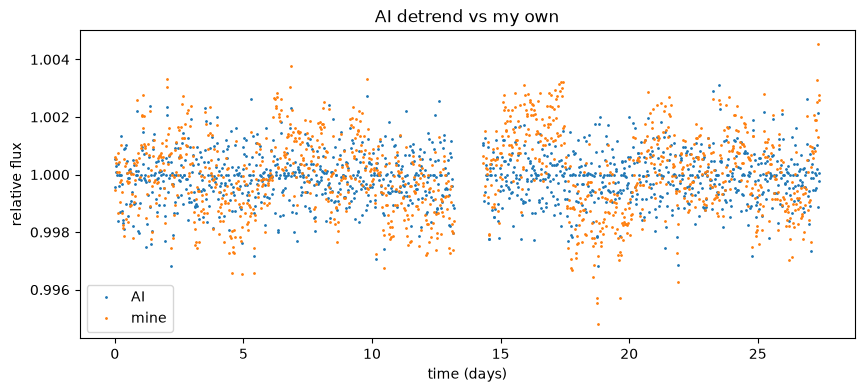

In [162]:
# Part 3: demonstrations here
cadence = np.median(np.diff(t))
window = max(3, int(round((6.0 / 24.) / cadence)))
trend = median_filter(flux, size=window)
flux_detrended = flux - trend + 1.0

plt.figure(figsize=(10, 4))
plt.plot(t, flux_detrended, '.', ms=2, label='AI')
plt.plot(t, flux_detrend, '.', ms=2, label='mine')
plt.xlabel('time (days)'); plt.ylabel('relative flux'); plt.legend()
plt.title('AI detrend vs my own')
plt.show()

t0 = 5.4289 d, P = 6.6630 d, depth = 1.427 ppt, duration = 2.07 h, baseline = 0.99991


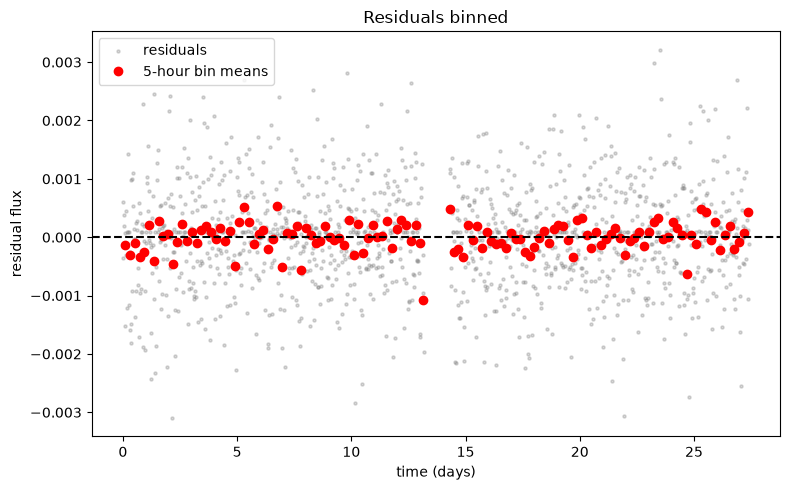

Ratio (observed/expected) = 0.8443


In [189]:
fname = f'data_03.csv'
with open(fname) as fh:
    alert = fh.readline()
P_alert = float(alert.split('P_alert =')[1].split('d')[0])
t0_alert = float(alert.split('t0_alert =')[1].split('d')[0])

sigma_emp = np.std(flux_detrended)

def transit_model(tt, t0, period, depth, duration, baseline, ingress_frac=0.2):
    ph = ((tt - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(tt)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

def neg_log_like(theta, tt, ff, sig):
    return 0.5 * np.sum(((ff - transit_model(tt, *theta)) / sig)**2)

# start from the community-alert ephemeris and refine
depth_guess = 1.0 - np.sort(flux_detrended)[20]
p0 = [t0_alert, P_alert, min(depth_guess, 0.008), 2.5 / 24., 1.0]

best = None
for dp in (0.998, 1.0, 1.002):
    for dt0 in (-0.1, -0.05, 0.0, 0.05, 0.1):
        start = [p0[0] + dt0, p0[1] * dp, p0[2], p0[3], p0[4]]
        res = minimize(neg_log_like, start, args=(t, flux_detrended, sigma_emp),
                       method='Nelder-Mead', options=dict(maxiter=20000))
        if best is None or res.fun < best.fun:
            best = res
theta = best.x
t0_fit, P_fit, depth_fit, dur_fit, base_fit = theta
print(f"t0 = {t0_fit:.4f} d, P = {P_fit:.4f} d, depth = {depth_fit*1e3:.3f} ppt,"
      f" duration = {dur_fit*24:.2f} h, baseline = {base_fit:.5f}")

resid = flux_detrended - transit_model(t, t0_fit, P_fit, depth_fit, dur_fit, base_fit, ingress_frac=0.2)
sigma_unbinned = np.std(resid)

bin_width = 5 / 24.0   

edges = np.arange(t.min(), t.max() + bin_width, bin_width)

bin_centers = []
bin_means = []
n_per_bin = []

for i in range(len(edges) - 1):

    mask = (t >= edges[i]) & (t < edges[i+1])

    if np.sum(mask) > 1:

        bin_centers.append(np.mean(t[mask]))
        bin_means.append(np.mean(resid[mask]))
        n_per_bin.append(np.sum(mask))

bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
n_per_bin = np.array(n_per_bin)

sigma_binned = np.std(bin_means)

N_eff = np.mean(n_per_bin)

sigma_expected = sigma_unbinned / np.sqrt(N_eff)

plt.figure(figsize=(8,5))

plt.scatter(
    t,
    resid,
    s=5,
    alpha=0.3,
    color="gray",
    label="residuals"
)

plt.plot(
    bin_centers,
    bin_means,
    "ro",
    label="5-hour bin means"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("time (days)")
plt.ylabel("residual flux")
plt.title("Residuals binned")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Ratio (observed/expected) = {sigma_binned/sigma_expected:.4f}")

In [224]:
print(sigma_emp)

0.0009098691681913971


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

I used Copilot for coding help throughout the lab. For part 1 this involved asking how I would implement spline to detrend the curve and methods I could use to choose the best parameters. For part 2 this involved writing the Gaussian log-likelihood, maximizing it, uncertainty calculations, and plots. It gave a suggestion on how to interpret the comparison of binned scatter and independent noise. For part 4 this included the code for simulating a light curve.

If there was a concept I did not understand or error in the code I wrote myself, I would ask for advice and sources. Any code was compared against what we discussed in lecture or previous methods I used in lab when possible. Markdown answers were written by myself.

**VERIFICATION PLAN:**

For verification I simulated a light curve to see if I could recover the expected values that I put in. I was looking for resulting values and uncertainties that lied within the truth of what I put in. If the values fell too far out of the truth I gave this would suggest something wrong with my process. The values I recovered were in line with my expected result.